**Load the Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import(train_test_split,RandomizedSearchCV,StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import(confusion_matrix,ConfusionMatrixDisplay,classification_report,roc_auc_score,roc_curve,precision_score,)
import joblib as jb
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
print("All libraries loaded✅")

All libraries loaded✅


**Load the dataset**

In [2]:
df = pd.read_excel("/content/E Commerce Dataset.xlsx", sheet_name="E Comm")
print(f"Dataset shape rows:{df.shape[0]} columns: {df.shape[1]}")
df

Dataset shape rows:5630 columns: 20


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90


**Eda & Wrangling**

In [3]:
print(df.head(5))
print(df.info())

   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN                Phone         1              8.0   
2       50003      1     NaN                Phone         1             30.0   
3       50004      1     0.0                Phone         3             15.0   
4       50005      1     0.0                Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0           Debit Card  Female             3.0                         3   
1                  UPI    Male             3.0                         4   
2           Debit Card    Male             2.0                         4   
3           Debit Card    Male             2.0                         4   
4                   CC    Male             NaN                         3   

     PreferedOrderCat  SatisfactionScore MaritalStatus  Number

**Finding the Churn**

In [4]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True)*100
print("_____Churn distribution_____")
print(f"stayed(0):{churn_counts[0]:,}({churn_pct[0]:.1f})")
print(f"Churned(1):{churn_counts[1]:,}({churn_pct[1]:.1f})")

_____Churn distribution_____
stayed(0):4,682(83.2)
Churned(1):948(16.8)


**Make the Distribution**

Text(0, 0.5, 'Count')

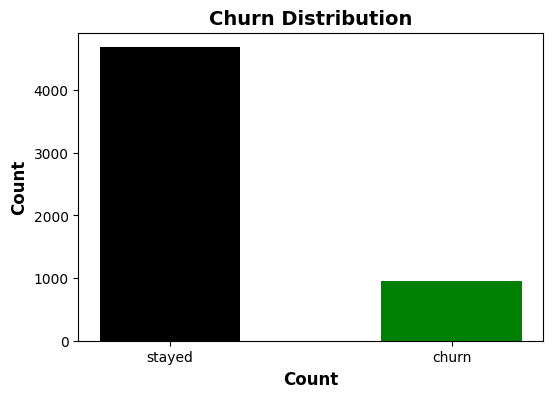

In [5]:
fig,ax=plt.subplots(figsize=(6,4))
ax.bar(["stayed","churn"],churn_counts.values,color=['black','green'],width=0.5)
ax.set_title("Churn Distribution",fontsize=14,fontweight="bold")
ax.set_xlabel("Count",fontsize=12,fontweight="bold")
ax.set_ylabel("Count",fontsize=12,fontweight="bold")

**Encoding**

In [6]:
Label = LabelEncoder()
df['PreferredLoginDevice'] = Label.fit_transform(df['PreferredLoginDevice'])
df['PreferredPaymentMode'] = Label.fit_transform(df['PreferredPaymentMode'])
df['Gender'] = Label.fit_transform(df['Gender'])
df['PreferedOrderCat'] = Label.fit_transform(df['PreferedOrderCat'])
df['MaritalStatus'] = Label.fit_transform(df['MaritalStatus'])
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,1,3,6.0,4,0,3.0,3,2,2,2,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,2,1,8.0,6,1,3.0,4,3,3,2,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,2,1,30.0,4,1,2.0,4,3,3,2,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,2,3,15.0,4,1,2.0,4,2,5,2,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,2,1,12.0,0,1,NaN,3,3,5,2,3,0,11.0,1.0,1.0,3.0,129.60


**Cleaning the data**

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f'\n✅ Missing values after fix: {df.isnull().sum().sum()}')

Columns with missing values:
Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64

✅ Missing values after fix: 0


**Feature selection**

In [8]:
features = [
    'Tenure',
    'WarehouseToHome',
    'NumberOfDeviceRegistered',
    'SatisfactionScore',
    'NumberOfAddress',
    'Complain',
    'DaySinceLastOrder',
    'CashbackAmount',
]

X = df[features]
y = df['Churn']
print(df.describe())

         CustomerID        Churn       Tenure  PreferredLoginDevice  \
count   5630.000000  5630.000000  5630.000000           5630.000000   
mean   52815.500000     0.168384    10.134103              0.928419   
std     1625.385339     0.374240     8.357951              0.709822   
min    50001.000000     0.000000     0.000000              0.000000   
25%    51408.250000     0.000000     3.000000              0.000000   
50%    52815.500000     0.000000     9.000000              1.000000   
75%    54222.750000     0.000000    15.000000              1.000000   
max    55630.000000     1.000000    61.000000              2.000000   

          CityTier  WarehouseToHome  PreferredPaymentMode       Gender  \
count  5630.000000      5630.000000           5630.000000  5630.000000   
mean      1.654707        15.566785              3.548135     0.601066   
std       0.915389         8.345961              1.389659     0.489723   
min       1.000000         5.000000              0.000000     0.

**Make the boxplot**

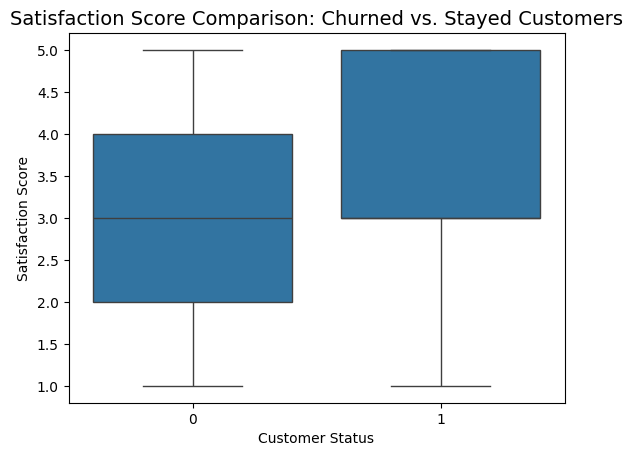

In [9]:
sns.boxplot(x='Churn', y='SatisfactionScore', data=df)
plt.title('Satisfaction Score Comparison: Churned vs. Stayed Customers', fontsize=14)
plt.xlabel('Customer Status')
plt.ylabel('Satisfaction Score')
plt.show()

**Find the targeted variable**

In [10]:
X = df.drop(columns="Churn")
y = df['Churn']

**Train the model on the Test and Train split**

In [11]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)

**Train the model on LogisticRegression**

In [12]:
model = LogisticRegression()
model.fit(X_train,Y_train)

LogisticRegression()

**Train the model on SVM**

In [13]:
modeL = SVC(kernel="rbf")
modeL.fit(X_train,Y_train)

SVC()

### Confusion Matrix for Logistic Regression

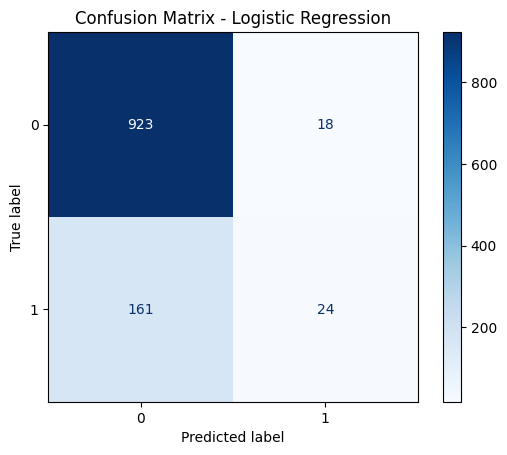

In [14]:
y_pred_lr = model.predict(X_test)
cm_lr = confusion_matrix(Y_test, y_pred_lr, labels=model.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=model.classes_)
disp_lr.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### Confusion Matrix for SVM

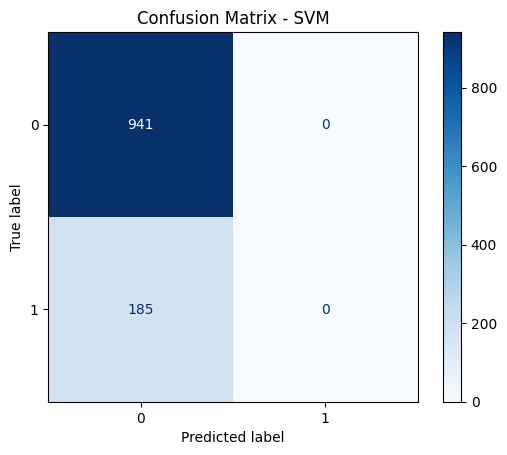

In [16]:
y_pred_svm = modeL.predict(X_test)
cm_svm = confusion_matrix(Y_test, y_pred_svm, labels=modeL.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=modeL.classes_)
disp_svm.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - SVM')
plt.show()

In [34]:
import pandas as pd
tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(Y_test, y_pred_lr).ravel()
results = pd.DataFrame({
    'Metric': ['True Negative', 'False Positive', 'False Negative', 'True Positive'],
    'Logistic Regression': [tn_lr, fp_lr, fn_lr, tp_lr],
    'SVM': [tn_svm, fp_svm, fn_svm, tp_svm]})
display(results)

,Metric,Logistic Regression,SVM
0,True Negative,923,941
1,False Positive,18,0
2,False Negative,161,185
3,True Positive,24,0
